# Simple Biopol LCA - with CITA numbers
Simple LCA for CITA's biopolymer panel. Includes the following processes: 
- 3D printing the panel 
- Pea protein binder
- Hemp dust filler
- Sea grass filler 

# Brightway project setup 

- A bw2 environment, project and database loaded with an ecoinvent copy need to be available in a separate local folder to be used by LcPy to derive the unit impacts of the sub-processes.
- be sure to use conda env `bw2`
- script was copied from [bw2 tutorial](https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html#)

In [1]:
import bw2io as bi
import bw2data as bd
import bw2calc as bc
import pandas as pd 

In [2]:
print(list(bd.projects)) #the prefix "bd" indicates that "projects" is a method of the bw2data package
bd.projects.set_current('biopol_lca') # activates a project, or creates it first if it doesn't exist yet
# bd.projects.migrate_project_25() 
print(list(bd.databases)) # check if there are databases in the project, and how they are named. 

[Project: default, Project: RAW_Reblakk, Project: Reblakk_2ndTry, Project: OpenLCA_Conversion, Project: RAW_timber_structure, Project: RAW_timber_structure_apos, Project: biopol_lca, Project: dummy_project, Project: biopol_lca_backup_ecoinvent_v391]
['lca_database_3DPrintedBiopol', 'biosphere-3.12', 'ecoinvent-3.12-cutoff']


In [3]:
bi.utils.DEFAULT_REQUEST_TIMEOUT = 600  # 600 seconds = 10 minutes

if 'ecoinvent-3.12-cutoff' in bd.databases:
    print('ecoinvent 3.12 is already present in the project')
else:
    bi.import_ecoinvent_release(
        version='3.12',
        system_model='cutoff', # can be cutoff / apos / consequential / EN15804
        username='LUCML',
        password='ecoV3JG62,0'
    )

ecoinvent 3.12 is already present in the project


# Add activities in activity-browser
The main processes are being added using the GUI activity-browser. See [MURAL board](https://app.mural.co/t/phd8054/m/phd8054/1756974417787/814130911a62286de97df9a05934b4ede2e1108f) for progress

# Calculate flow amounts
Calculate technosphere input flows based on assumptions, explicitly shown below in Python code

In [4]:
[node for node in bd.Database('lca_database_3DPrintedBiopol')]

['milling' (kilogram, GLO, None),
 'aqueous mixing' (kilogram, GLO, None),
 'seagrass filler production' (kilogram, GLO, None),
 '3D printing' (kilogram, RER, None),
 'centrifugation' (kilogram, GLO, None),
 'membrane filtration' (kilogram, GLO, None),
 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None),
 'Drying with dehumidifying chamber' (kilogram, RER, None),
 'hemp dust filler production' (kilogram, GLO, None),
 'pea protein binder production' (kilogram, GLO, None)]

## Drying

In [5]:
'''
Parameters for drying process calculations
- local climate conditions (temperature, relative humidity, atmospheric pressure)
- drying chamber conditions (volume, air infiltration rate, drying time, temperature, relative humidity)
- material drying conditions (number and dimensions of panels, water content, target evaporation percentage)
'''

# local climate conditions 
climate_temperature = 20 # °C
climate_relative_humidity = 0.8 # 50% relative humidity
climate_atmospheric_pressure = 101325 # Pa (sea level standard atmospheric pressure)

# drying chamber conditions
chamber_temperature = 20 
chamber_relative_humidity = 0.2 
drying_chamber_volume = 5 * 6 * 3
air_infiltration_per_hour = 1 # value for average building. Can be as low as 0.1 for well-sealed buildings
drying_time = 2 * 7 * 24 # hours (2 weeks)

# material drying conditions 
n_panels = 100 
liters_per_panel = 0.5 * 0.5 * 0.05 * 1000
liters_material = n_panels * liters_per_panel
g_water_per_liter_material = 682 # source: Carl for xantham gum 
density_material_g_per_liter = 850 # source: Carl, typically between 800-900 g/L 
evaporation_target = 0.75 # 70-80% of water needs to be evaporated 

# COP (coefficient of performance) for heating, cooling, and dehumidification 
# the higher the value, the more efficient the system 
cop_heating = 3 # typical value for electric heat pump
cop_cooling = 3 # typical value for electric heat pump
cop_dehumidification = 2 # typical value for electric dehumidifier

''' 
Calculations for energy required for drying
- calculate mass of water in the air to be removed (based on absolute humidity difference between outdoors and chamber, and volume of air to be processed)
- calculate mass of water in the wet material to be removed (based on water content of the material and target evaporation percentage)
- calculate energy required for drying (based on enthalpy of vaporization of water at the chamber temperature, and mass
'''

# get absolute humidity and dry air density
import psychrolib
psychrolib.SetUnitSystem(psychrolib.SI) # use SI units
absolute_humidity_outdoors = psychrolib.GetHumRatioFromRelHum(climate_temperature, climate_relative_humidity, climate_atmospheric_pressure) 
absoloute_humidity_chamber = psychrolib.GetHumRatioFromRelHum(chamber_temperature, chamber_relative_humidity, climate_atmospheric_pressure)
air_density = 1.2

# calculate mass of water in the air to be removed 
m3_air = drying_chamber_volume * air_infiltration_per_hour * drying_time # m3
kg_water_to_remove_from_air = (absolute_humidity_outdoors - absoloute_humidity_chamber) * m3_air * air_density # kg

# calculate mass of water in wet material
kg_water_in_wet_material = g_water_per_liter_material * liters_material / 1000 # convert g to kg
kg_water_to_remove_from_material = kg_water_in_wet_material * evaporation_target # kg of water to be removed from the material

# calculate energy required for drying 
enthalpy_of_vaporization = 2501 - 2.37 * chamber_temperature # standard rule-of-thumb formula for enthalpy of vaporization of water at different temperatures (kJ/kg)
kwh_energy_required_for_air = kg_water_to_remove_from_air * enthalpy_of_vaporization / 3600 / cop_dehumidification # convert kJ to kWh
kwh_energy_required_for_material = kg_water_to_remove_from_material * enthalpy_of_vaporization / 3600 / cop_dehumidification # convert kJ to kWh
kwh_energy_required_for_dehumidification = kwh_energy_required_for_air + kwh_energy_required_for_material
print("Dehumidification calculations:")
print(f"Energy required for drying air (kWh): {kwh_energy_required_for_air:.2f} ({kwh_energy_required_for_air / kwh_energy_required_for_dehumidification * 100:.1f}%)")
print(f"Energy required for drying material (kWh): {kwh_energy_required_for_material:.2f} ({kwh_energy_required_for_material / kwh_energy_required_for_dehumidification * 100:.1f}%)")
print(f"Energy required for drying (kWh): {kwh_energy_required_for_dehumidification:.2f}\n")

'''
Reference values for energy required for drying (source: Carl)
'''
# energy required for drying based on Carl's info: 4 machines, 255W per machine, 2 weeks of drying time
n_machines = 4 
w_per_machine = 255 
total_energy_kWh = n_machines * w_per_machine * drying_time / 1000
print(f"Reference energy required for drying (kWh): {total_energy_kWh:.2f}\n")

''' 
Calculate energy required for temperature control 
'''
kg_air = m3_air * air_density # kg of air to be processed
specific_heat_air = 1.005 # kJ/kg*K
temperature_difference = chamber_temperature - climate_temperature # K
kwh_energy_required_for_temperature_control = kg_air * specific_heat_air * temperature_difference / 3600 # convert kJ to kWh
if kwh_energy_required_for_temperature_control == 0:
    kwh_energy_required_for_temperature_control = 0 
elif kwh_energy_required_for_temperature_control < 0:
    kwh_energy_required_for_temperature_control = abs(kwh_energy_required_for_temperature_control) / cop_cooling # cooling is required, adjust for COP
else: 
    kwh_energy_required_for_temperature_control = kwh_energy_required_for_temperature_control / cop_heating # heating is required, adjust for COP
print("Temperature control calculations:")
print(f"Energy required for temperature control (kWh): {kwh_energy_required_for_temperature_control:.2f}\n")

''' 
Save results to brightway2 database
'''

# calculate kg wet material per kg dry material
kg_wetMaterial = liters_material * density_material_g_per_liter / 1000 # convert g to kg
kg_dryMaterial = kg_wetMaterial - kg_water_to_remove_from_material
kg_wetMaterial_perKg_dry = kg_wetMaterial / kg_dryMaterial

# convert energy required to per kg of dry material
kwh_energy_required_total = kwh_energy_required_for_dehumidification + kwh_energy_required_for_temperature_control
kwh_energy_required_per_kg_dry = kwh_energy_required_total / kg_dryMaterial

# calculate units of dehumidifier required 
hrs_lifetime_demumidifier = 25 * 365 * 24 # hours (25 year lifetime)
units_consumed_per_cycle = drying_time / hrs_lifetime_demumidifier
units_dehumidifier_perKg_dry = units_consumed_per_cycle / kg_dryMaterial

def modify_amounts(node, input_name, amount):
    edge = [edge for edge in node.edges() if input_name in edge.input['name']][0]
    edge['amount'] = amount
    edge.save()

input_amounts = {
    'Kiln baking - 150 degress for 2 hours': kg_wetMaterial_perKg_dry,
    'market for electricity, medium voltage': kwh_energy_required_per_kg_dry,
    'blower and heat exchange unit production, decentralized, 180-250 m3/h': units_dehumidifier_perKg_dry,
}

node_drying = bd.get_node(name='Drying with dehumidifying chamber', database='lca_database_3DPrintedBiopol')
for input_name, amount in input_amounts.items():
    modify_amounts(node_drying, input_name, amount)
list(node_drying.technosphere())

Dehumidification calculations:
Energy required for drying air (kWh): 109.02 (33.3%)
Energy required for drying material (kWh): 217.88 (66.7%)
Energy required for drying (kWh): 326.91

Reference energy required for drying (kWh): 342.72

Temperature control calculations:
Energy required for temperature control (kWh): 0.00



[Exchange: 2.511078286558346 kilogram 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 3.6259889520649114e-06 unit 'blower and heat exchange unit production, decentralized, 180-250 m3/h' (unit, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 0.7726037297614555 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>]

## Baking

In [6]:
# AMOUNTS FOR BAKING PROCESS

# base assumptions
kg_output = 1  # kg of baked panel that we want to produce
hrs_baking = 0  # 2 hours baking time at 150°C
kg_per_panel = 3.5  # weight of one wet panel in kg
n_panels_per_kiln = 3  # number of panels that fit in the kiln at once

# kg of wet panel that needs to be baked
# assumption: baking drives off moisture, panels lose ~10% of weight
kg_wetPanel_perKg_bakedPanel = kg_output * 1  # kg of wet panel needed to produce 1 kg of baked panel
print(f'kg of wet panel needed to produce {kg_output} kg of baked panel: {kg_wetPanel_perKg_bakedPanel} kg')

# kwh of electricity
# assumption: mid-sized light industrial kiln, estimated at 5 kW average draw during baking cycle
# note: kilns do not draw peak power continuously — heating elements cycle on/off to maintain
# temperature, so average draw is typically 50-70% of rated power. 5 kW is a conservative
# midpoint for a unit rated at ~6-8 kW.
kwh_perHr_kiln = 5  # kWh per hour, estimated for mid-sized light industrial kiln
kg_wetPanel_perKiln = n_panels_per_kiln * kg_per_panel  # kg of wet panel per kiln load
kwh_electricity_perBatch = kwh_perHr_kiln * hrs_baking  # kWh per baking batch
kwh_electricity_perKg_bakedPanel = kwh_electricity_perBatch / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)
print(f'kwh of electricity needed to bake {kg_output} kg of baked panel: {kwh_electricity_perKg_bakedPanel} kwh')

# units of kiln
# baking is a batch process, so we allocate by number of batches rather than continuous hours
hrs_lifetime_kiln = 25 * 365 * 24  # 25 years of lifetime, in hours
hrs_kiln_perKg_bakedPanel = hrs_baking / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)  # kiln-hours per kg output
units_kiln_perKg_bakedPanel = hrs_kiln_perKg_bakedPanel / hrs_lifetime_kiln
print(f'units of kiln needed to bake {kg_output} kg of baked panel: {units_kiln_perKg_bakedPanel} units')

# save amounts in bw database
node_baking = bd.get_node(name='Kiln baking - 150 degress for 2 hours', database='lca_database_3DPrintedBiopol')
input_amounts = {
    '3D printing': kg_wetPanel_perKg_bakedPanel,
    'market for electricity, medium voltage': kwh_electricity_perKg_bakedPanel,
    'market for industrial furnace, natural gas': units_kiln_perKg_bakedPanel,
}
for input_name, amount in input_amounts.items():
    modify_amounts(node_baking, input_name, amount)
list(node_baking.technosphere())  # check if the changes have been applied correctly

kg of wet panel needed to produce 1 kg of baked panel: 1 kg
kwh of electricity needed to bake 1 kg of baked panel: 0.0 kwh
units of kiln needed to bake 1 kg of baked panel: 0.0 units


[Exchange: 1 kilogram '3D printing' (kilogram, RER, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 0.0 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 0.0 unit 'market for industrial furnace, natural gas' (unit, GLO, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>]

## 3D printing

In [ ]:
# AMOUNTS FOR 3D PRINTING PROCESS — first-principles approach
# All flows are per kg of wet output (the material as it comes off the printer).

# ── Material composition (from recipe) ───────────────────────────────────────
density_total_g_per_L  = 850   # g/L; midpoint of 800–900 g/L
density_water_g_per_L  = 682   # g/L; water content from biopol recipe
density_total_kg_per_L = density_total_g_per_L / 1000

# ── Print rate and electricity ────────────────────────────────────────────────
# Carl's machine prints at 4 litres per hour at 0.4 kW power draw.
# (Max is 0.58 kW at 2m/s; typical operation is 50mm/s ≈ 0.4 kW)
print_rate_L_per_hr  = 4.0    # litres per hour
power_printer_kW     = 0.4    # kW at typical operating speed

print_rate_kg_per_hr = print_rate_L_per_hr * density_total_kg_per_L   # kg wet output per hour
hrs_per_kg_wet       = 1 / print_rate_kg_per_hr                        # hours to print 1 kg

kwh_electricity_perKg_wet = power_printer_kW * hrs_per_kg_wet

print(f'Print rate:              {print_rate_kg_per_hr:.2f} kg/hr')
print(f'Hours per kg wet output: {hrs_per_kg_wet:.4f} hrs')
print(f'→ kWh electricity per kg wet output: {kwh_electricity_perKg_wet:.5f}')

# ── Printer capital equipment wear ────────────────────────────────────────────
# Allocated by print-hours consumed per kg of wet output.
kg_printer           = 1000          # kg; estimated for medium industrial robotic arm
hrs_lifetime_printer = 25 * 365 * 24 # 25-year lifetime in hours

units_printer_perKg_wet = hrs_per_kg_wet / hrs_lifetime_printer
kg_printer_perKg_wet    = units_printer_perKg_wet * kg_printer

print(f'\n→ kg of printer per kg wet output: {kg_printer_perKg_wet:.8f}')

# ── Material inputs ───────────────────────────────────────────────────────────
# Fractions are kg of each input per kg of wet output.
# Water is assumed to be embedded in the input materials (from the recipe).
fraction_pea_protein = 0.7
fraction_hemp_dust   = 0.2
fraction_seagrass    = 0.1

print(f'\nMaterial inputs per kg wet output:')
print(f'  Pea protein binder: {fraction_pea_protein} kg')
print(f'  Hemp dust filler:   {fraction_hemp_dust} kg')
print(f'  Seagrass filler:    {fraction_seagrass} kg')
print(f'  Total:              {fraction_pea_protein + fraction_hemp_dust + fraction_seagrass} kg')

# ── Save to brightway database ────────────────────────────────────────────────
def modify_amounts(node, input_name, amount):
    edge = [edge for edge in node.edges() if input_name in edge.input['name']][0]
    edge['amount'] = amount
    edge.save()

input_amounts = {
    'market for electricity, medium voltage':          kwh_electricity_perKg_wet,
    'industrial machine production, heavy, unspecified': kg_printer_perKg_wet,
    'pea protein binder production':                   fraction_pea_protein,
    'hemp dust filler production':                     fraction_hemp_dust,
    'seagrass filler production':                      fraction_seagrass,
}

node_printing = bd.get_node(name='3D printing', database='lca_database_3DPrintedBiopol')
for input_name, amount in input_amounts.items():
    modify_amounts(node_printing, input_name, amount)
list(node_printing.technosphere())

Print rate:              3.40 kg/hr
Hours per kg wet output: 0.2941 hrs
→ kWh electricity per kg wet output: 0.11765

→ kg of printer per kg wet output: 0.00134300

Material inputs per kg wet output:
  Pea protein binder: 0.5 kg
  Hemp dust filler:   0.3 kg
  Seagrass filler:    0.2 kg
  Total:              1.0 kg


[Exchange: 0.11764705882352942 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.0013430029546065002 kilogram 'industrial machine production, heavy, unspecified' (kilogram, RER, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.3 kilogram 'hemp dust filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.5 kilogram 'pea protein binder production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.2 kilogram 'seagrass filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>]

## Transportation 

In [ ]:
# calculate transportation distance limit 
acceptable_transport_cost_share = 0.05  # 5% of product value can be spent on transportation
product_value_per_ton = 2000 
transport_cost_per_ton_km = 0.1  # typical cost for road freight in USD per ton-km
max_transport_distance = (acceptable_transport_cost_share * product_value_per_ton) / transport_cost_per_ton_km

def calculate_max_transport_distance(acceptable_transport_cost_share, product_value_per_ton, transport_cost_per_ton_km):
    return (acceptable_transport_cost_share * product_value_per_ton) / transport_cost_per_ton_km

In [8]:
def calculate_ton_km(km_distance, kg_material=1):
    # ton-km = weight (in tons) x distance (in km)
    return kg_material / 1000 * km_distance 

travel_distances = {
    'pea protein binder production': 100,  # example distance in km
    'hemp dust filler production': 100,  # example distance in km
    'seagrass filler production': 100,  # example distance in km
}

for material_name, km_distance in travel_distances.items():
    node = bd.get_node(name=material_name, database='lca_database_3DPrintedBiopol')
    ton_km = calculate_ton_km(km_distance=km_distance, kg_material=1)
    modify_amounts(node, 'market for transport, freight, lorry, unspecified', ton_km)
    print(material_name)
    for edge in node.technosphere(): 
        print(edge)
    print('')

pea protein binder production
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'pea protein binder production' (kilogram, GLO, None)>
Exchange: 1 kilogram 'membrane filtration' (kilogram, GLO, None) to 'pea protein binder production' (kilogram, GLO, None)>

hemp dust filler production
Exchange: 1 kilogram 'carding waste, hemp to generic market for cellulose fibre' (kilogram, FR, None) to 'hemp dust filler production' (kilogram, GLO, None)>
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'hemp dust filler production' (kilogram, GLO, None)>

seagrass filler production
Exchange: 1 kilogram 'flax straw production, dew-retted' (kilogram, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>
Exchange: 0.1 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>



## Pea protein production

In [9]:
# function for calculating kwh energy for chemical production process
def calculate_kwh_electricity(hrs_process, kwh_perHr, machine_capacity_kg=1000):
    kwh_electricity_perMachine = hrs_process * kwh_perHr
    kwh_electricity = kwh_electricity_perMachine / machine_capacity_kg
    return kwh_electricity

# function for calculating kg of machinery needed 
def calculate_kg_machinery(hrs_process, hrs_lifetime, kg_per_unit, machine_capacity_kg=1000):
    units_needed = hrs_process / hrs_lifetime
    kg_machinery = units_needed * kg_per_unit
    kg_machinery_perKg_material = kg_machinery / machine_capacity_kg
    return kg_machinery_perKg_material

assumptions_dict = {
    'membrane filtration': {
        'hrs_process': 3, 
        'kwh_perHr': 3,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 200, 
        'machine_capacity_kg': 500, 
    }, 
    'centrifugation': {
        'hrs_process': 2, 
        'kwh_perHr': 7,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 800, 
        'machine_capacity_kg': 500, 
    }, 
    'aqueous mixing': {
        'hrs_process': 4, 
        'kwh_perHr': 1.5,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 300, 
        'machine_capacity_kg': 500, 
    }, 
    'milling': {
        'hrs_process': 2, 
        'kwh_perHr': 10,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 1000, 
        'machine_capacity_kg': 500, 
    }, 
}

for process_name, assumptions in assumptions_dict.items():
    node = bd.get_node(name=process_name, database='lca_database_3DPrintedBiopol')
    kwh_electricity = calculate_kwh_electricity(hrs_process=assumptions['hrs_process'], kwh_perHr=assumptions['kwh_perHr'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    kg_machinery = calculate_kg_machinery(hrs_process=assumptions['hrs_process'], hrs_lifetime=assumptions['hrs_lifetime'], kg_per_unit=assumptions['kg_per_unit'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    modify_amounts(node, 'electricity, medium voltage', kwh_electricity)
    modify_amounts(node, 'industrial machine, heavy, unspecified', kg_machinery)
    print(process_name)
    for edge in node.technosphere():
        print(edge)


membrane filtration
Exchange: 1 kilogram 'centrifugation' (kilogram, GLO, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 0.018 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 5.479452054794521e-06 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'membrane filtration' (kilogram, GLO, None)>
centrifugation
Exchange: 1 kilogram 'aqueous mixing' (kilogram, GLO, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 0.028 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 1.4611872146118723e-05 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'centrifugation' (kilogram, GLO, None)>
aqueous mixing
Exchange: 1 kilogram 'milling' (kilogram, GLO, None) to 'aqueous mixing' (kilogram, GLO, None)>
Exchange: 1 kilogram 'market for pro

# LCIA

In [10]:
# select method for LCA calculation
list(bd.methods)
cml_methods = [method for method in bd.methods if method[0] == 'CML v4.8 2016 no LT']
cml_gwp_key = [method for method in cml_methods if 'global warming' in method[2]].pop() 
cml_gwp_key

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [11]:
cml_methods[1]

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [12]:
# calculate all activities using all methods in cml_methods 
db = bd.Database('lca_database_3DPrintedBiopol')

# print overview of activities 
print('summary of activities in our database:')
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    print(f'{id} - {name}')

# define functional units and methods for multi-LCA calculation
functional_units = {}
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    functional_units[name] = {db.get(name=name).id:1}
config = {'impact_categories': [cml_methods[1]]}
data_objs = bd.get_multilca_data_objs(functional_units=functional_units, method_config=config)

# calculate multi-LCA
mlca_2 = bc.MultiLCA(demands=functional_units, method_config=config, data_objs=data_objs)
mlca_2.lci()
mlca_2.lcia()

summary of activities in our database:
25957 - Drying with dehumidifying chamber
25959 - 3D printing
310744122832863232 - hemp dust filler production
310744071972732928 - seagrass filler production
310717486095810560 - pea protein binder production
310747592356937728 - milling
310746682058752000 - membrane filtration
310747495627898880 - aqueous mixing
25958 - Kiln baking - 150 degress for 2 hours
310747240719073280 - centrifugation


In [13]:
# visualize results

# create dataframe with results
dfresults = pd.DataFrame.from_dict(mlca_2.scores, orient='index')
dfresults.index = pd.MultiIndex.from_tuples(dfresults.index, names=['Column', 'Row'])
dfresults = dfresults.unstack(level=0)
dfresults

# # make bar chart
# import matplotlib.pyplot as plt
# dfresults.plot(kind="barh")
# ax = plt.subplot(111)
# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height, box.width, box.height])
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# plt.show()

,0
Column,"(CML v4.8 2016 no LT, climate change no LT, global warming potential (GWP100) no LT)"
Row,
3D printing,0.392652
Drying with dehumidifying chamber,1.385960
Kiln baking - 150 degress for 2 hours,0.392652
aqueous mixing,0.430776
centrifugation,0.445272
hemp dust filler production,0.156861
membrane filtration,0.454581
milling,0.020702


In [27]:
# basic contribution analysis 
import bw2analyzer as bwa
ca = bwa.utils.recursive_calculation_to_object(
    db.get(name='Drying with dehumidifying chamber'),
    cml_methods[-3], # material resources
    amount=1,  # How much of the activity? (same as in our FU)
    max_level=5,  # How many levels deep in the CA do you want to go?
)
ca = pd.DataFrame(ca)
ca.head() 

,label,parent,score,fraction,amount,name,key
0,root,None,7.524249e-06,1.000000,1.000000,Drying with dehumidifying chamber,"(lca_database_3DPrintedBiopol, f81ed13fd5614c9..."
1,root_a,root,6.826166e-06,0.907222,2.511078,Kiln baking - 150 degress for 2 hours,"(lca_database_3DPrintedBiopol, f71ee748eecf4b6..."
2,root_a_a,root_a,6.826166e-06,0.907222,2.511078,3D printing,"(lca_database_3DPrintedBiopol, b8fd832602d2463..."
3,root_a_a_a,root_a_a,2.454096e-07,0.032616,0.295421,"market for electricity, medium voltage","(ecoinvent-3.12-cutoff, 2bf03d6f26170fb34a9a28..."
4,root_a_a_a_b,root_a_a_a,1.274270e-07,0.016936,0.288555,electricity voltage transformation from high t...,"(ecoinvent-3.12-cutoff, cc0b114d5860e380a3df0f..."


In [28]:
import plotly.graph_objects as go
import pandas as pd

# --- build node and link lists for Sankey ---
labels = ca["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

# short display names (truncate long ecoinvent names)
def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca.iterrows():
    if row["parent"] is None:
        continue
    src = label_to_idx[row["label"]]      # child → parent (reversed)
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca.loc[ca.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA acidification impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

In [45]:
import plotly.graph_objects as go
import pandas as pd

# --- define cutoff nodes: anything upstream of these will be hidden ---
cutoff_names = {
    'market for electricity, medium voltage',
    'market for electricity, high voltage',
    'electricity voltage transformation from high to medium voltage',
    # add any other names you want to treat as terminal nodes
}

# find the labels corresponding to cutoff nodes
cutoff_labels = set(ca.loc[ca["name"].isin(cutoff_names), "label"])

# keep only rows that are NOT upstream of a cutoff node
# i.e. drop any row whose parent label is in cutoff_labels
ca_filtered = ca[~ca["parent"].isin(cutoff_labels)].copy()

# --- build node and link lists from filtered dataframe ---
labels = ca_filtered["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca_filtered.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca_filtered.iterrows():
    if row["parent"] is None or row["parent"] not in label_to_idx:
        continue
    src = label_to_idx[row["label"]]
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca_filtered.loc[ca_filtered.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="perpendicular",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA GWP impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

# Sensitivity analysis 

## Local climate --> drying energy use --> environmental impact

In [23]:
"""
Sensitivity Analysis: Effect of Local Climate on Drying Energy and LCA Impact
==============================================================================
Varies temperature and relative humidity across European climate extremes and
shows the deviation from the baseline result as tornado charts — one per
CML v4.8 impact category.

Prerequisites
-------------
- A Brightway2 project called 'biopol_lca' with:
    - ecoinvent-3.12-cutoff loaded
    - lca_database_3DPrintedBiopol populated and all flow amounts set
      (run the main notebook first to set the baseline amounts)
- psychrolib installed  (pip install psychrolib)
- plotly installed      (pip install plotly)
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import bw2data as bd
import bw2calc as bc
import psychrolib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import copy

psychrolib.SetUnitSystem(psychrolib.SI)

# ── Activate project ──────────────────────────────────────────────────────────
bd.projects.set_current('biopol_lca')
db = bd.Database('lca_database_3DPrintedBiopol')


# =============================================================================
# 1.  European climate extremes
# =============================================================================
# Temperature range: from a cold continental winter (Helsinki, Jan avg ≈ -5 °C)
# to a hot Mediterranean summer (Seville, Jul avg ≈ 35 °C).
# Relative humidity: from dry continental/inland conditions (~30 %)
# to persistently damp Atlantic/Nordic conditions (~90 %).
#
# Sources:
#   - Koppen-Geiger climate classification for Europe
#   - Eurostat / ECA&D monthly climate normals (1991-2020)

CLIMATE_SCENARIOS = {
    # (label, temperature °C, relative humidity 0-1)
    "Cold & dry\n(e.g. Moscow, Jan)"  : (-5,  0.65),
    "Cold & humid\n(e.g. Bergen, Jan)": (-2,  0.90),
    "Baseline\n(temperate, 20 °C)"   : (20,  0.80),   # ← notebook baseline
    "Warm & dry\n(e.g. Madrid, Jul)" : (32,  0.30),
    "Hot & humid\n(e.g. Athens, Aug)": (35,  0.70),
}


# =============================================================================
# 2.  Drying energy calculation (mirrors the notebook exactly)
# =============================================================================
def calculate_drying_energy(climate_temperature: float,
                             climate_relative_humidity: float) -> dict:
    """
    Return a dict with:
        kwh_energy_required_per_kg_dry   – electricity input to the drying node
        kg_wetMaterial_perKg_dry         – wet-material input to baking node
        units_dehumidifier_perKg_dry     – dehumidifier capital input
    """
    # ── Fixed parameters (unchanged from notebook) ─────────────────────────
    climate_atmospheric_pressure = 101325  # Pa

    chamber_temperature        = 20        # °C  (controlled)
    chamber_relative_humidity  = 0.2
    drying_chamber_volume      = 5 * 6 * 3  # m³
    air_infiltration_per_hour  = 1          # ACH
    drying_time                = 2 * 7 * 24 # hours (2 weeks)

    n_panels                   = 100
    liters_per_panel           = 0.5 * 0.5 * 0.05 * 1000
    liters_material            = n_panels * liters_per_panel
    g_water_per_liter_material = 682
    density_material_g_per_liter = 850
    evaporation_target         = 0.75

    cop_heating        = 3
    cop_cooling        = 3
    cop_dehumidification = 2

    hrs_lifetime_dehumidifier = 25 * 365 * 24

    # ── Psychrometrics ──────────────────────────────────────────────────────
    absolute_humidity_outdoors = psychrolib.GetHumRatioFromRelHum(
        climate_temperature, climate_relative_humidity,
        climate_atmospheric_pressure)
    absolute_humidity_chamber  = psychrolib.GetHumRatioFromRelHum(
        chamber_temperature, chamber_relative_humidity,
        climate_atmospheric_pressure)
    air_density = 1.2  # kg/m³ (approx)

    # ── Water to remove from infiltrating air ──────────────────────────────
    m3_air = drying_chamber_volume * air_infiltration_per_hour * drying_time
    humidity_difference = absolute_humidity_outdoors - absolute_humidity_chamber

    # If outdoor air is DRIER than the chamber it actually helps — clamp to 0
    # (the dehumidifier only has to work on the moisture from the material).
    kg_water_to_remove_from_air = max(
        humidity_difference * m3_air * air_density, 0.0)

    # ── Water to remove from the material ──────────────────────────────────
    kg_water_in_wet_material       = g_water_per_liter_material * liters_material / 1000
    kg_water_to_remove_from_material = kg_water_in_wet_material * evaporation_target

    # ── Dehumidification energy ─────────────────────────────────────────────
    enthalpy_of_vaporization = 2501 - 2.37 * chamber_temperature  # kJ/kg
    kwh_for_air      = (kg_water_to_remove_from_air
                        * enthalpy_of_vaporization / 3600
                        / cop_dehumidification)
    kwh_for_material = (kg_water_to_remove_from_material
                        * enthalpy_of_vaporization / 3600
                        / cop_dehumidification)
    kwh_dehumidification = kwh_for_air + kwh_for_material

    # ── Temperature-control energy ──────────────────────────────────────────
    kg_air = m3_air * air_density
    specific_heat_air = 1.005  # kJ/(kg·K)
    delta_T = chamber_temperature - climate_temperature

    kwh_temp_control_raw = kg_air * specific_heat_air * delta_T / 3600
    if delta_T == 0:
        kwh_temp_control = 0.0
    elif delta_T < 0:
        # outdoor warmer than chamber → need cooling
        kwh_temp_control = abs(kwh_temp_control_raw) / cop_cooling
    else:
        # outdoor colder than chamber → need heating
        kwh_temp_control = kwh_temp_control_raw / cop_heating

    # ── Totals per kg dry material ──────────────────────────────────────────
    kwh_total = kwh_dehumidification + kwh_temp_control

    kg_wet_material = liters_material * density_material_g_per_liter / 1000
    kg_dry_material = kg_wet_material - kg_water_to_remove_from_material

    kwh_per_kg_dry          = kwh_total / kg_dry_material
    kg_wet_per_kg_dry       = kg_wet_material / kg_dry_material
    units_consumed_per_cycle = drying_time / hrs_lifetime_dehumidifier
    units_dehumidifier_per_kg_dry = units_consumed_per_cycle / kg_dry_material

    return {
        'kwh_energy_required_per_kg_dry' : kwh_per_kg_dry,
        'kg_wetMaterial_perKg_dry'       : kg_wet_per_kg_dry,
        'units_dehumidifier_perKg_dry'   : units_dehumidifier_per_kg_dry,
    }


# =============================================================================
# 3.  Helper: update the drying node in brightway, run LCIA, restore original
# =============================================================================
def modify_amounts(node, input_name: str, amount: float):
    edge = [e for e in node.edges() if input_name in e.input['name']][0]
    edge['amount'] = amount
    edge.save()


def get_drying_node():
    return bd.get_node(name='Drying with dehumidifying chamber',
                       database='lca_database_3DPrintedBiopol')


def run_lcia_with_climate(climate_temperature: float,
                           climate_relative_humidity: float,
                           functional_units: dict,
                           method_config: dict) -> dict:
    """
    Temporarily patch drying-node amounts for the given climate,
    run multi-LCA, restore originals, return scores dict.

    data_objs is intentionally built AFTER patching the database so that
    bw2calc reads the updated edge amounts rather than cached stale values.
    """
    amounts = calculate_drying_energy(climate_temperature,
                                      climate_relative_humidity)
    node_drying = get_drying_node()

    # --- snapshot original amounts so we can restore them ---
    PATCH_KEYS = [
        'market for electricity, medium voltage',
        'blower and heat exchange unit production',
        'Kiln baking',
    ]
    originals = {}
    for edge in node_drying.edges():
        for key in PATCH_KEYS:
            if key in edge.input['name']:
                originals[edge.input['name']] = edge['amount']

    # --- apply new amounts and save to the database ---
    input_amounts = {
        'market for electricity, medium voltage'                               : amounts['kwh_energy_required_per_kg_dry'],
        'blower and heat exchange unit production, decentralized, 180-250 m3/h': amounts['units_dehumidifier_perKg_dry'],
        'Kiln baking - 150 degress for 2 hours'                               : amounts['kg_wetMaterial_perKg_dry'],
    }
    for input_name, amount in input_amounts.items():
        modify_amounts(node_drying, input_name, amount)

    # --- rebuild data_objs NOW so bw2calc picks up the saved changes ---
    data_objs = bd.get_multilca_data_objs(functional_units=functional_units,
                                           method_config=method_config)

    # --- run LCIA ---
    mlca = bc.MultiLCA(demands=functional_units,
                       method_config=method_config,
                       data_objs=data_objs)
    mlca.lci()
    mlca.lcia()
    scores = copy.deepcopy(mlca.scores)

    # --- restore originals ---
    for input_name, original_amount in originals.items():
        modify_amounts(node_drying, input_name, original_amount)

    return scores


# =============================================================================
# 4.  Main sensitivity loop
# =============================================================================
cml_methods = [m for m in bd.methods if m[0] == 'CML v4.8 2016 no LT']
print(f"Found {len(cml_methods)} CML methods.")

# Build functional units for all activities
functional_units = {}
for act in db:
    functional_units[act['name']] = {db.get(name=act['name']).id: 1}

# Collect results per scenario
all_results = {}  # scenario_label -> scores dict

for label, (temp, rh) in CLIMATE_SCENARIOS.items():
    print(f"Running scenario: {label.strip()} (T={temp}°C, RH={rh*100:.0f}%)...")
    config = {'impact_categories': cml_methods}
    scores = run_lcia_with_climate(temp, rh, functional_units, config)
    all_results[label] = scores
    print(f"  → done.")

print("\nAll scenarios complete. Building tornado charts...")


# =============================================================================
# 5.  Restructure results for plotting
# =============================================================================
BASELINE_LABEL = "Baseline\n(temperate, 20 °C)"
TARGET_ACTIVITY = 'Drying with dehumidifying chamber'

# ── Inspect the actual key structure from the baseline scores ─────────────────
# mlca.scores keys can be (demand_key, method_tuple) or (method_tuple, demand_key)
# depending on bw2calc version. We detect empirically.
baseline_scores_raw = all_results[BASELINE_LABEL]
sample_key = next(iter(baseline_scores_raw))
print(f"\nDEBUG — sample scores key : {sample_key}")
print(f"DEBUG — sample value      : {baseline_scores_raw[sample_key]}")
print(f"DEBUG — total keys        : {len(baseline_scores_raw)}")

def scores_to_tidy(scores_dict: dict, scenario_label: str) -> pd.DataFrame:
    """
    Convert an mlca.scores dict to a long-form DataFrame:
        scenario | demand_key | method | value

    Works regardless of whether the key tuple is (demand, method) or (method, demand).
    Methods are always 3-element tuples of strings; demand keys are plain strings.
    """
    df = pd.DataFrame.from_dict(scores_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['level_0', 'level_1'])
    df = df.reset_index()

    # Identify which level is the demand key (str) vs the method (tuple of 3 str)
    first_l0 = df['level_0'].iloc[0]
    if isinstance(first_l0, str):
        demand_level, method_level = 'level_0', 'level_1'
    else:
        demand_level, method_level = 'level_1', 'level_0'

    df = df.rename(columns={demand_level: 'demand_key', method_level: 'method'})
    df['scenario'] = scenario_label
    return df[['scenario', 'demand_key', 'method', 'value']]

# Build one big tidy frame across all scenarios
df_tidy = pd.concat(
    [scores_to_tidy(scores, label) for label, scores in all_results.items()],
    ignore_index=True,
)

print(f"\nDEBUG — unique demand_keys : {df_tidy['demand_key'].unique()}")
print(f"DEBUG — unique methods     : {len(df_tidy['method'].unique())}")

# Filter to the drying activity only
df_drying = df_tidy[df_tidy['demand_key'] == TARGET_ACTIVITY].copy()

if df_drying.empty:
    raise ValueError(
        f"No scores found for '{TARGET_ACTIVITY}'.\n"
        f"Unique demand_keys present: {df_tidy['demand_key'].unique()}\n"
        "Adjust TARGET_ACTIVITY to match one of these exactly."
    )

# Pivot: rows = scenarios, columns = methods
df_summary = df_drying.pivot(index='scenario', columns='method', values='value')

# Baseline row
df_baseline = df_summary.loc[BASELINE_LABEL]

Found 11 CML methods.
Running scenario: Cold & dry
(e.g. Moscow, Jan) (T=-5°C, RH=65%)...
  → done.
Running scenario: Cold & humid
(e.g. Bergen, Jan) (T=-2°C, RH=90%)...
  → done.
Running scenario: Baseline
(temperate, 20 °C) (T=20°C, RH=80%)...
  → done.
Running scenario: Warm & dry
(e.g. Madrid, Jul) (T=32°C, RH=30%)...
  → done.
Running scenario: Hot & humid
(e.g. Athens, Aug) (T=35°C, RH=70%)...
  → done.

All scenarios complete. Building tornado charts...

DEBUG — sample scores key : (('CML v4.8 2016 no LT', 'acidification no LT', 'acidification (incl. fate, average Europe total, A&B) no LT'), 'aqueous mixing')
DEBUG — sample value      : 0.0018678809181996553
DEBUG — total keys        : 110

DEBUG — unique demand_keys : ['aqueous mixing' 'hemp dust filler production' '3D printing'
 'membrane filtration' 'Drying with dehumidifying chamber' 'milling'
 'centrifugation' 'Kiln baking - 150 degress for 2 hours'
 'pea protein binder production' 'seagrass filler production']
DEBUG — uniq

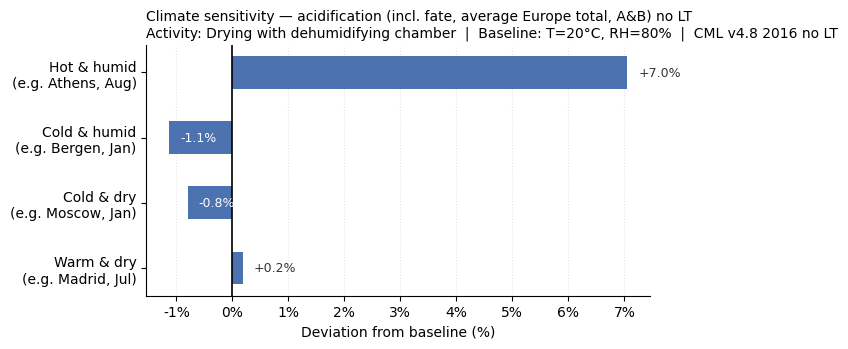

  Saved: png/260520_tornado_localClimateOnDrying_acidification_incl._fate_average_Europe_total_A&B_no_LT.png


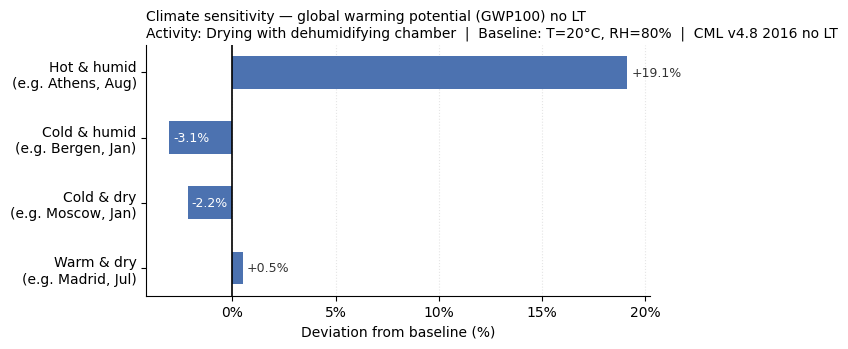

  Saved: png/260520_tornado_localClimateOnDrying_global_warming_potential_GWP100_no_LT.png


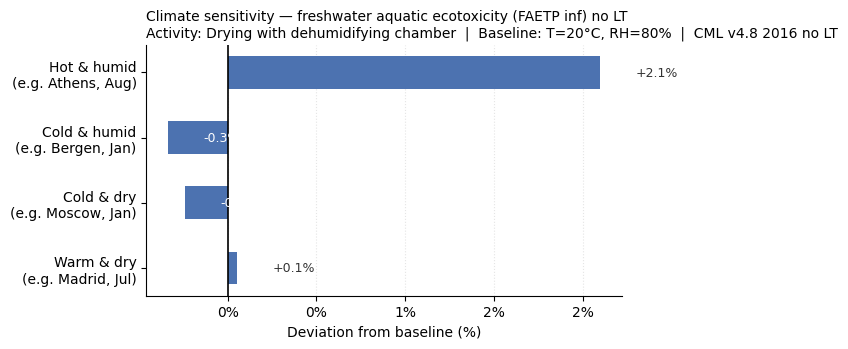

  Saved: png/260520_tornado_localClimateOnDrying_freshwater_aquatic_ecotoxicity_FAETP_inf_no_LT.png


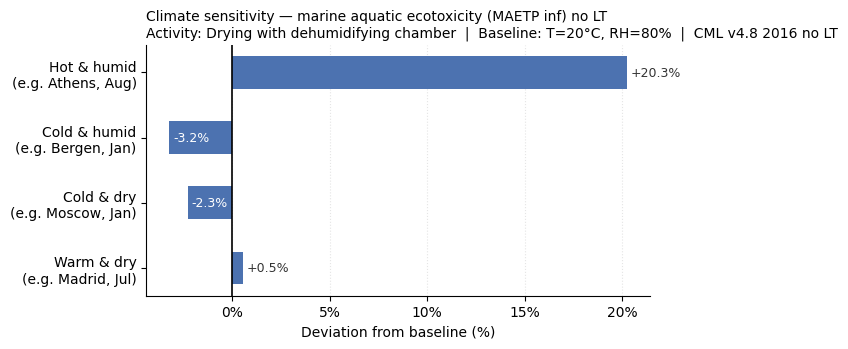

  Saved: png/260520_tornado_localClimateOnDrying_marine_aquatic_ecotoxicity_MAETP_inf_no_LT.png


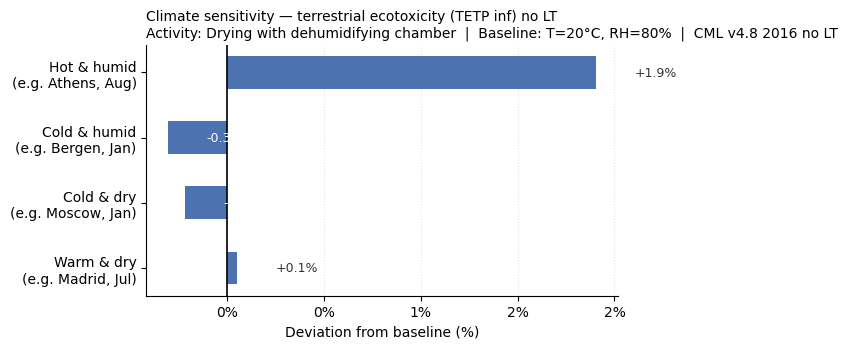

  Saved: png/260520_tornado_localClimateOnDrying_terrestrial_ecotoxicity_TETP_inf_no_LT.png


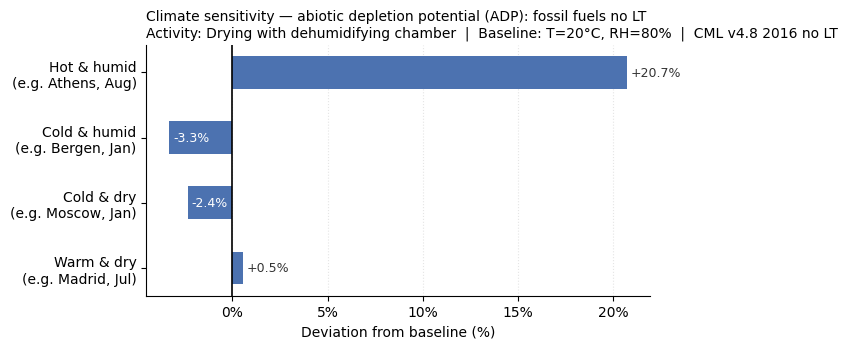

  Saved: png/260520_tornado_localClimateOnDrying_abiotic_depletion_potential_ADP:_fossil_fuels_no_LT.png


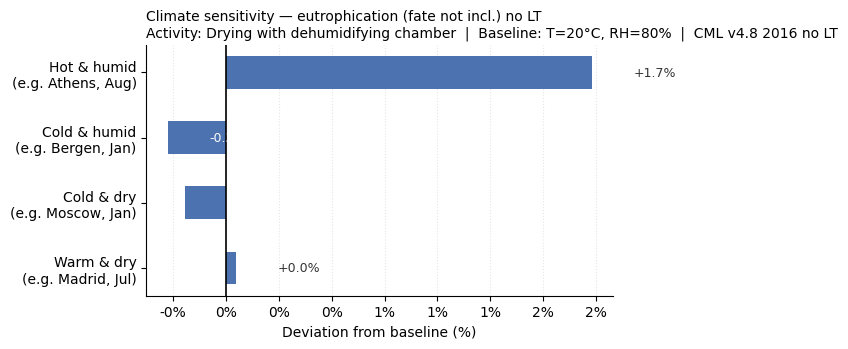

  Saved: png/260520_tornado_localClimateOnDrying_eutrophication_fate_not_incl._no_LT.png


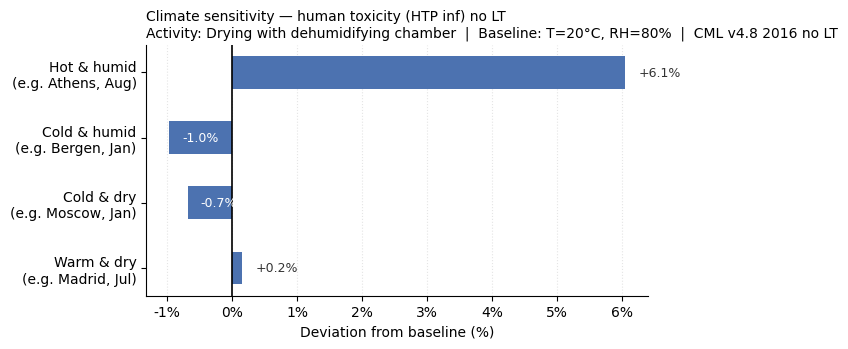

  Saved: png/260520_tornado_localClimateOnDrying_human_toxicity_HTP_inf_no_LT.png


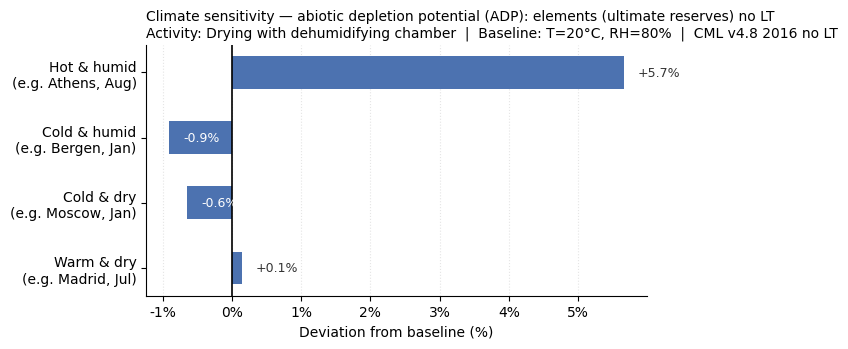

  Saved: png/260520_tornado_localClimateOnDrying_abiotic_depletion_potential_ADP:_elements_ultimate_reserves_no_LT.png


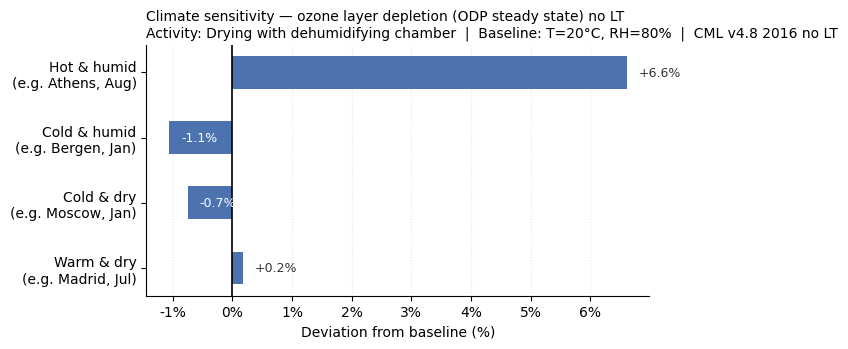

  Saved: png/260520_tornado_localClimateOnDrying_ozone_layer_depletion_ODP_steady_state_no_LT.png


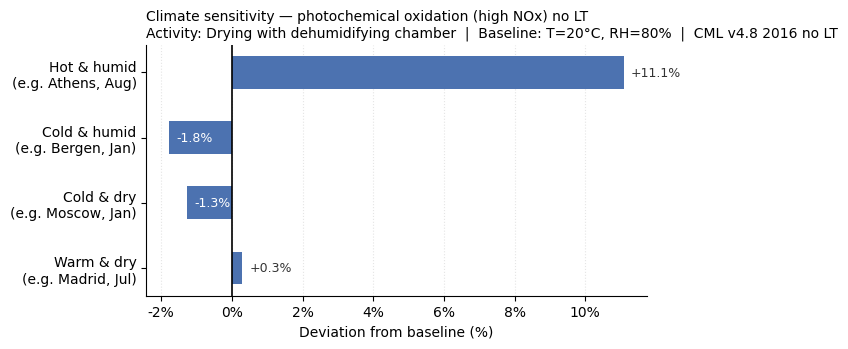

  Saved: png/260520_tornado_localClimateOnDrying_photochemical_oxidation_high_NOx_no_LT.png

Done. All tornado charts saved.


In [24]:
# =============================================================================
# 6.  Tornado charts — one per impact category (matplotlib)
# =============================================================================
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
scenario_labels = [s for s in CLIMATE_SCENARIOS.keys() if s != BASELINE_LABEL]
 
base_dir = '../results/sensitivity_analysis'
png_dir  = os.path.join(base_dir, 'png')
os.makedirs(png_dir, exist_ok=True)
 
for method in cml_methods:
    baseline_val = df_baseline.get(method, np.nan)
    if pd.isna(baseline_val) or baseline_val == 0:
        continue
 
    method_name = method[2]
 
    # ── Compute % deviations ────────────────────────────────────────────────
    pct_deviations = []
    bar_labels     = []
    for label in scenario_labels:
        if method not in df_summary.columns:
            continue
        val = df_summary.at[label, method]
        if pd.isna(val):
            continue
        pct_deviations.append((val - baseline_val) / abs(baseline_val) * 100)
        bar_labels.append(label)
 
    if not pct_deviations:
        continue
 
    # Sort largest absolute deviation to top
    order      = np.argsort(np.abs(pct_deviations))[::-1]
    pct_sorted = [pct_deviations[i] for i in order]
    lbl_sorted = [bar_labels[i]     for i in order]
    n          = len(lbl_sorted)
 
    # ── Draw chart ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 1.4 + 0.55 * n))
 
    y_pos = range(n)
    ax.barh(y_pos, pct_sorted, color='#4C72B0', height=0.5)
 
    # Percentage labels: inside bar for negative, outside for positive
    for i, val in enumerate(pct_sorted):
        if val < 0:
            ax.text(val + 0.2, i, f"{val:+.1f}%",
                    va='center', ha='left', fontsize=9, color='white')
        else:
            ax.text(val + 0.2, i, f"{val:+.1f}%",
                    va='center', ha='left', fontsize=9, color='#333333')
 
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(lbl_sorted, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_xlabel("Deviation from baseline (%)", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_title(
        f"Climate sensitivity — {method_name}\n"
        f"Activity: {TARGET_ACTIVITY}  |  Baseline: T=20°C, RH=80%  |  CML v4.8 2016 no LT",
        fontsize=10, loc='left'
    )
    ax.grid(axis='x', color='#e5e5e5', linestyle=':', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
 
    plt.tight_layout()
 
    # ── Save ────────────────────────────────────────────────────────────────
    safe_name = (method_name
                 .replace('/', '-').replace(' ', '_')
                 .replace(',', '').replace('(', '').replace(')', ''))
    stem     = f"260520_tornado_localClimateOnDrying_{safe_name}"
    png_path = os.path.join(png_dir, f"{stem}.png")
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.show()   # display inline in the notebook
    plt.close()  # release memory
    print(f"  Saved: png/{stem}.png")
 
print("\nDone. All tornado charts saved.")

## Material fractions --> 3D printing inputs --> environmental impact

In [ ]:
"""
Sensitivity Analysis: Effect of Material Fractions on 3D Printing LCA Impact
==============================================================================
Varies the kg-per-kg-wet-output fractions of pea protein binder, hemp dust
filler, and seagrass filler across plausible recipe extremes and shows the
deviation from the baseline result as tornado charts — one per CML v4.8
impact category.

Fraction ranges (must always sum to 1.0):
  fraction_pea_protein : 0.70 – 1.00  (baseline 0.70)
  fraction_hemp_dust   : 0.00 – 0.30  (baseline 0.20)
  fraction_seagrass    : 0.00 – 0.30  (baseline 0.10)

Scenarios follow a one-at-a-time (OAT) approach: each scenario pushes one
ingredient to its extreme while the remaining fraction distributes to the
others to keep the sum at 1.0, as close to the baseline split as possible.

Prerequisites
-------------
- A Brightway2 project 'biopol_lca' with lca_database_3DPrintedBiopol
  populated and all flow amounts already set (run the main notebook first).
- plotly and matplotlib installed
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import bw2data as bd
import bw2calc as bc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import copy
import os

# ── Activate project ──────────────────────────────────────────────────────────
bd.projects.set_current('biopol_lca')
db = bd.Database('lca_database_3DPrintedBiopol')


# =============================================================================
# 1.  Material-fraction scenarios
# =============================================================================
# Baseline: pea=0.70, hemp=0.20, seagrass=0.10  (from the 3D-printing cell)
#
# Each scenario varies one ingredient to its plausible extreme; the leftover
# fraction (1 − varied ingredient) is split between the other two in proportion
# to their baseline shares, so the mix remains physically valid (sum = 1.0).
#
# Scenario naming mirrors the climate block: short label with key parameter.

FRACTION_SCENARIOS = {
    # label : (pea_protein, hemp_dust, seagrass)
    "Baseline\n(pea=0.70, hemp=0.20, seagrass=0.10)" : (0.70, 0.20, 0.10),  # ← notebook baseline
    "Pea-heavy mix\n(pea=1.00, hemp=0.00, seagrass=0.00)" : (1.00, 0.00, 0.00),  # max pea
    "Hemp-heavy mix\n(pea=0.70, hemp=0.30, seagrass=0.00)" : (0.70, 0.30, 0.00),  # max hemp
    "Seagrass-heavy mix\n(pea=0.70, hemp=0.00, seagrass=0.30)" : (0.70, 0.00, 0.30),  # max seagrass
    "No seagrass\n(pea=0.80, hemp=0.20, seagrass=0.00)" : (0.80, 0.20, 0.00),  # seagrass removed, surplus to pea
    "No hemp\n(pea=0.80, hemp=0.00, seagrass=0.20)" : (0.80, 0.00, 0.20),  # hemp removed, surplus to pea
}

# Sanity check — all scenarios must sum to 1.0
for label, (pea, hemp, sg) in FRACTION_SCENARIOS.items():
    total = round(pea + hemp + sg, 10)
    assert total == 1.0, f"Fractions do not sum to 1.0 in scenario '{label}': {total}"


# =============================================================================
# 2.  Helper: update 3D-printing node fractions, run LCIA, restore originals
# =============================================================================
def modify_amounts(node, input_name: str, amount: float):
    edge = [e for e in node.edges() if input_name in e.input['name']][0]
    edge['amount'] = amount
    edge.save()


def get_printing_node():
    return bd.get_node(name='3D printing',
                       database='lca_database_3DPrintedBiopol')


def run_lcia_with_fractions(frac_pea: float,
                             frac_hemp: float,
                             frac_seagrass: float,
                             functional_units: dict,
                             method_config: dict) -> dict:
    """
    Temporarily patch the three material-input amounts on the 3D-printing node,
    run multi-LCA, restore the originals, and return the scores dict.

    data_objs is rebuilt AFTER patching so that bw2calc reads the updated
    edge amounts rather than cached stale values — same pattern as the
    climate sensitivity block.
    """
    node_printing = get_printing_node()

    # ── Snapshot current amounts so we can restore them ──────────────────────
    PATCH_KEYS = [
        'pea protein binder production',
        'hemp dust filler production',
        'seagrass filler production',
    ]
    originals = {}
    for edge in node_printing.edges():
        for key in PATCH_KEYS:
            if key in edge.input['name']:
                originals[edge.input['name']] = edge['amount']

    # ── Apply new fractions ───────────────────────────────────────────────────
    new_amounts = {
        'pea protein binder production' : frac_pea,
        'hemp dust filler production'   : frac_hemp,
        'seagrass filler production'    : frac_seagrass,
    }
    for input_name, amount in new_amounts.items():
        modify_amounts(node_printing, input_name, amount)

    # ── Rebuild data_objs so bw2calc sees the saved changes ──────────────────
    data_objs = bd.get_multilca_data_objs(functional_units=functional_units,
                                           method_config=method_config)

    # ── Run LCIA ─────────────────────────────────────────────────────────────
    mlca = bc.MultiLCA(demands=functional_units,
                       method_config=method_config,
                       data_objs=data_objs)
    mlca.lci()
    mlca.lcia()
    scores = copy.deepcopy(mlca.scores)

    # ── Restore original amounts ──────────────────────────────────────────────
    for input_name, original_amount in originals.items():
        modify_amounts(node_printing, input_name, original_amount)

    return scores


# =============================================================================
# 3.  Main sensitivity loop
# =============================================================================
cml_methods = [m for m in bd.methods if m[0] == 'CML v4.8 2016 no LT']
print(f"Found {len(cml_methods)} CML methods.")

# Build functional units for all activities
functional_units = {}
for act in db:
    functional_units[act['name']] = {db.get(name=act['name']).id: 1}

# Collect results per scenario
all_results = {}  # scenario_label -> scores dict

for label, (pea, hemp, sg) in FRACTION_SCENARIOS.items():
    print(f"Running scenario: {label.strip()} "
          f"(pea={pea}, hemp={hemp}, seagrass={sg})...")
    config = {'impact_categories': cml_methods}
    scores = run_lcia_with_fractions(pea, hemp, sg, functional_units, config)
    all_results[label] = scores
    print(f"  → done.")

print("\nAll scenarios complete. Building tornado charts...")


# =============================================================================
# 4.  Restructure results for plotting
# =============================================================================
BASELINE_LABEL  = "Baseline\n(pea=0.70, hemp=0.20, seagrass=0.10)"
TARGET_ACTIVITY = '3D printing'


def scores_to_tidy(scores_dict: dict, scenario_label: str) -> pd.DataFrame:
    """
    Convert an mlca.scores dict to a long-form DataFrame:
        scenario | demand_key | method | value

    Works regardless of whether the key tuple is (demand, method) or (method, demand).
    Methods are always 3-element tuples of strings; demand keys are plain strings.
    """
    df = pd.DataFrame.from_dict(scores_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['level_0', 'level_1'])
    df = df.reset_index()

    first_l0 = df['level_0'].iloc[0]
    if isinstance(first_l0, str):
        demand_level, method_level = 'level_0', 'level_1'
    else:
        demand_level, method_level = 'level_1', 'level_0'

    df = df.rename(columns={demand_level: 'demand_key', method_level: 'method'})
    df['scenario'] = scenario_label
    return df[['scenario', 'demand_key', 'method', 'value']]


# Build one big tidy frame across all scenarios
df_tidy = pd.concat(
    [scores_to_tidy(scores, label) for label, scores in all_results.items()],
    ignore_index=True,
)

print(f"\nDEBUG — unique demand_keys : {df_tidy['demand_key'].unique()}")
print(f"DEBUG — unique methods     : {len(df_tidy['method'].unique())}")

# Filter to the 3D printing activity
df_target = df_tidy[df_tidy['demand_key'] == TARGET_ACTIVITY].copy()

if df_target.empty:
    raise ValueError(
        f"No scores found for '{TARGET_ACTIVITY}'.\n"
        f"Unique demand_keys present: {df_tidy['demand_key'].unique()}\n"
        "Adjust TARGET_ACTIVITY to match one of these exactly."
    )

# Pivot: rows = scenarios, columns = methods
df_summary  = df_target.pivot(index='scenario', columns='method', values='value')
df_baseline = df_summary.loc[BASELINE_LABEL]


# =============================================================================
# 5.  Tornado charts — one per impact category (matplotlib)
# =============================================================================
scenario_labels = [s for s in FRACTION_SCENARIOS.keys() if s != BASELINE_LABEL]

base_dir = '../results/sensitivity_analysis'
png_dir  = os.path.join(base_dir, 'png')
os.makedirs(png_dir, exist_ok=True)

for method in cml_methods:
    baseline_val = df_baseline.get(method, np.nan)
    if pd.isna(baseline_val) or baseline_val == 0:
        continue

    method_name = method[2]

    # ── Compute % deviations ────────────────────────────────────────────────
    pct_deviations = []
    bar_labels     = []
    for label in scenario_labels:
        if method not in df_summary.columns:
            continue
        val = df_summary.at[label, method]
        if pd.isna(val):
            continue
        pct_deviations.append((val - baseline_val) / abs(baseline_val) * 100)
        bar_labels.append(label)

    if not pct_deviations:
        continue

    # Sort largest absolute deviation to top
    order      = np.argsort(np.abs(pct_deviations))[::-1]
    pct_sorted = [pct_deviations[i] for i in order]
    lbl_sorted = [bar_labels[i]     for i in order]
    n          = len(lbl_sorted)

    # ── Draw chart ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 1.4 + 0.55 * n))

    y_pos = range(n)
    ax.barh(y_pos, pct_sorted, color='#2ca02c', height=0.5)

    # Percentage labels
    for i, val in enumerate(pct_sorted):
        if val < 0:
            ax.text(val + 0.2, i, f"{val:+.1f}%",
                    va='center', ha='left', fontsize=9, color='white')
        else:
            ax.text(val + 0.2, i, f"{val:+.1f}%",
                    va='center', ha='left', fontsize=9, color='#333333')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(lbl_sorted, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_xlabel("Deviation from baseline (%)", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_title(
        f"Material fraction sensitivity — {method_name}\n"
        f"Activity: {TARGET_ACTIVITY}  |  Baseline: pea=0.70, hemp=0.20, seagrass=0.10  |  CML v4.8 2016 no LT",
        fontsize=10, loc='left'
    )
    ax.grid(axis='x', color='#e5e5e5', linestyle=':', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()

    # ── Save ────────────────────────────────────────────────────────────────
    safe_name = (method_name
                 .replace('/', '-').replace(' ', '_')
                 .replace(',', '').replace('(', '').replace(')', ''))
    stem     = f"260520_tornado_materialFractionsOn3Dprinting_{safe_name}"
    png_path = os.path.join(png_dir, f"{stem}.png")
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Saved: png/{stem}.png")

print("\nDone. All tornado charts saved.")
